In [37]:
### From TEMPO2 TO timing residuals plots
### tempo2 -nofit -output general2 -s "{bat} {post} {err}\n" -outfile M2A_demo.txt -f M2A_demo.par M2A.tim
### Dejiang Yin, 2026/01/21

In [38]:
# ============================================================
# Timing residual visualization from tempo2 general2 output
#
# Expected input columns:
#   1) {bat}  : Barycentric Arrival Time (MJD)
#   2) {post} : Post-fit timing residual (seconds)
#   3) {err}  : Post-fit residual uncertainty (nanoseconds)
#
# Residuals and uncertainties are converted to microseconds
# for plotting.
# ============================================================
# ------------------------------------------------------------
# Import required libraries
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import os
# ------------------------------------------------------------
# Jupyter configuration for high-quality inline figures
# ------------------------------------------------------------
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

plt.rcParams['font.family'] = 'DejaVu Sans'   # Change if needed
plt.rcParams['font.size'] = 15
plt.rcParams['axes.linewidth'] = 0.8

In [39]:
# ------------------------------------------------------------
# Step 1: Define input data file
# ------------------------------------------------------------
data_file = r'E:\Docker\data\Workshop\plot\tempo2\M2A_demo.txt'

In [40]:
# ------------------------------------------------------------
# Step 2: Read tempo2 general2 output
# ------------------------------------------------------------
bat_mjd = []        # Barycentric arrival time (MJD)
residual_s = []     # Post-fit residual (seconds)
residual_err_ns = []  # Residual uncertainty (nanoseconds)

if not os.path.exists(data_file):
    raise FileNotFoundError(f"Input file not found: {data_file}")

with open(data_file, 'r', encoding='utf-8') as f:
    for line_number, line in enumerate(f, start=1):
        parts = line.strip().split()

        # Each valid data line must contain exactly three columns
        if len(parts) != 3:
            print(
                f"Warning: line {line_number} does not have 3 columns. "
                f"Skipping."
            )
            continue

        try:
            bat_mjd.append(float(parts[0]))
            residual_s.append(float(parts[1]))
            residual_err_ns.append(float(parts[2]))
        except ValueError as exc:
            print(
                f"Warning: could not parse line {line_number}. "
                f"Skipping. Error: {exc}"
            )

In [41]:
# ------------------------------------------------------------
# Step 3: Convert to NumPy arrays and check data
# ------------------------------------------------------------
bat_mjd = np.asarray(bat_mjd)
residual_s = np.asarray(residual_s)
residual_err = np.asarray(residual_err_ns)

print("Data import summary:")
print(f"  Number of data points : {len(bat_mjd)}")

if len(bat_mjd) == 0:
    raise RuntimeError("No valid data points found.")

# Unit conversion
#   seconds  -> microseconds
#   nanoseconds -> microseconds
residual_us = residual_s * 1e6

print(f"  BAT range (MJD)       : {bat_mjd.min():.6f} – {bat_mjd.max():.6f}")
print(f"  Residual range (μs)  : {residual_us.min():.3f} – {residual_us.max():.3f}")
print(f"  Error range (μs)     : {residual_err.min():.3f} – {residual_err.max():.3f}")


Data import summary:
  Number of data points : 243
  BAT range (MJD)       : 58795.478109 – 60511.772880
  Residual range (μs)  : -232.914 – 165.789
  Error range (μs)     : 28.404 – 200.806


Figure saved to: E:\Docker\data\Workshop\plot\tempo2\M2A_postfit_residuals.pdf


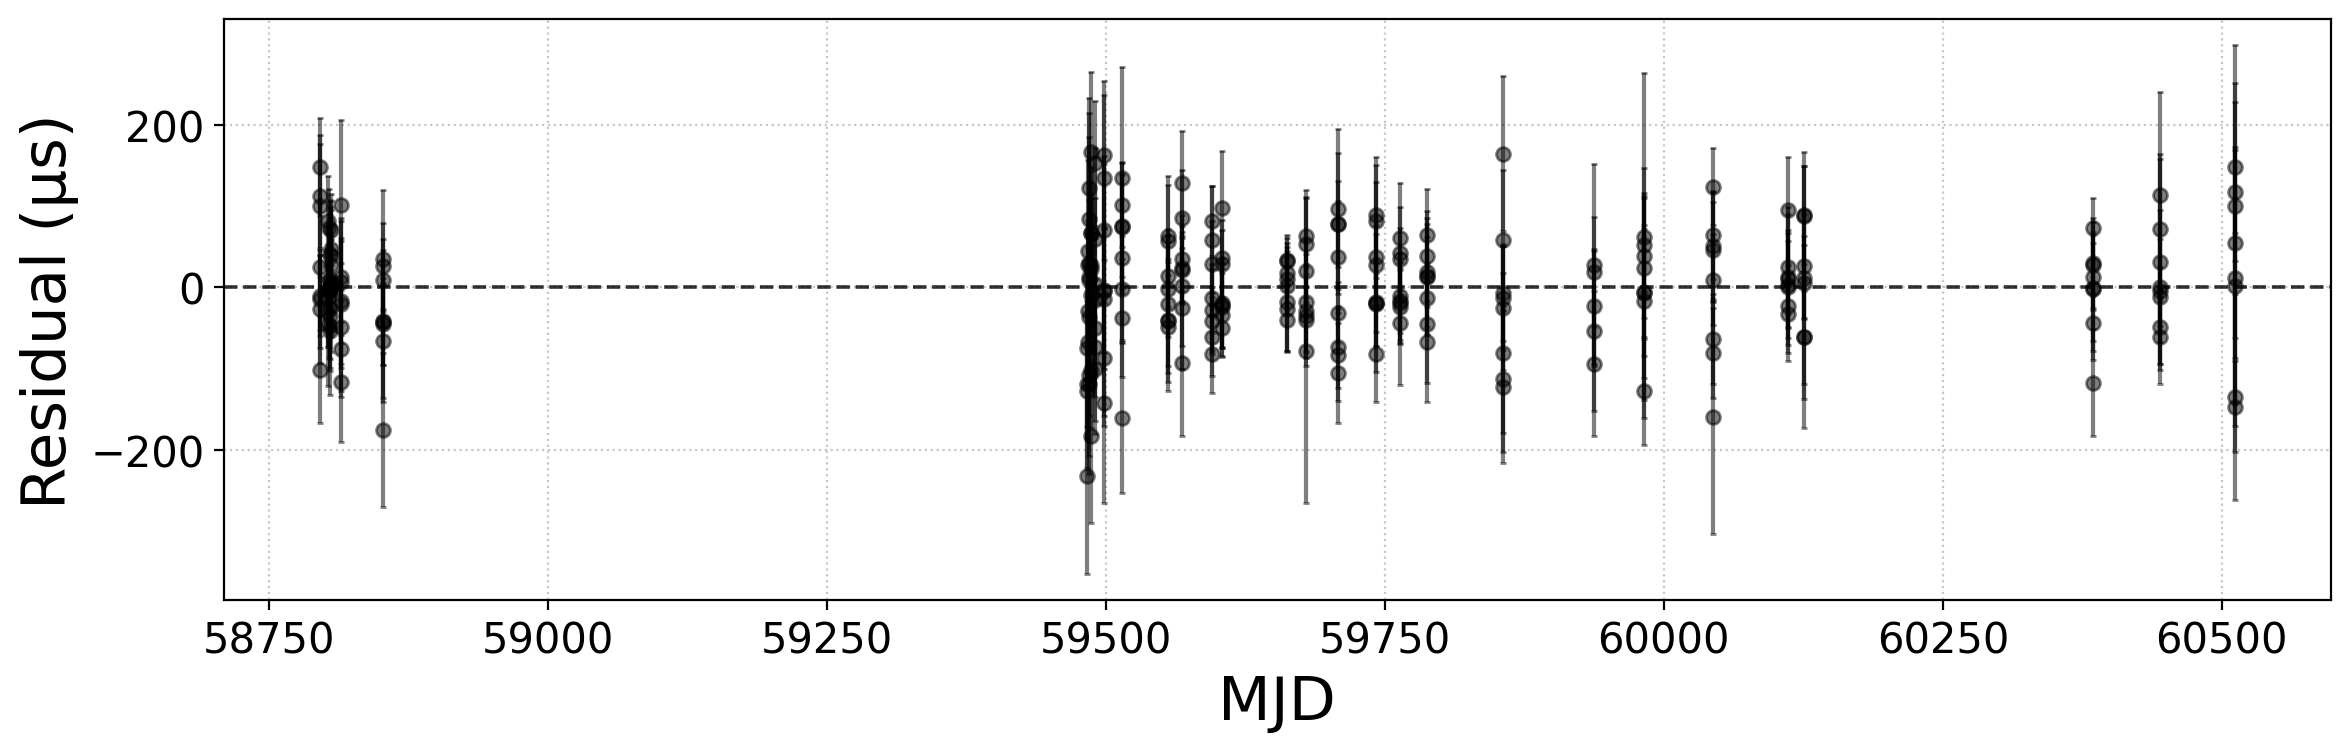

In [42]:
# ------------------------------------------------------------
# Step 4: Plot post-fit residuals with error bars
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(
    bat_mjd,
    residual_us,
    yerr=residual_err,
    fmt='o',
    markersize=5,
    color='black',
    ecolor='black',
    elinewidth=1.5,
    capsize=1,
    alpha=0.5,
)

# Zero-residual reference line
ax.axhline(
    0.0,
    color='black',
    linestyle='--',
    linewidth=1.3,
    alpha=0.8
)

# Axis labels
ax.set_xlabel('MJD', fontsize=22)
ax.set_ylabel('Residual (μs)', fontsize=22)

# Grid styling
ax.grid(
    True,
    linestyle=':',
    linewidth=0.8,
    alpha=0.7
)

plt.tight_layout()
# ------------------------------------------------------------
# Step 5: Save figure
# ------------------------------------------------------------
output_figure = r'E:\Docker\data\Workshop\plot\tempo2\M2A_postfit_residuals.pdf'
plt.savefig(output_figure, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_figure}")
plt.show()

In [43]:
#    # tempo2 -f <parfile> <timfile> \
#           -output general2 \
#           -s "{var1} {var2} ...\n" \
#           -outfile output.txt

In [44]:
#   tempo2 general2 — Complete Variable Reference
#   This document is compiled directly from the tempo2 general2 plugin source code. It lists the variables and control directives that can be used inside the general2 format string (via -s or -file). This reference is derived directly from the tempo2 general2 plugin source code. It lists commonly used variables and control directives for scripting, PTA analyses, MCMC, and automated pipelines.
#   ### Dejiang Yin /2026/01/21
#   1.general usage
#   
#   # the following * from: https://github.com/OZGrav/meerpipe/blob/main/tempo2_wrapper.sh
#   
#   echo "Generating residuals"
#   echo "----------------------------------"
#   # general2 is a tempo2 pluggin: https://github.com/mattpitkin/tempo2/blob/master/plugin/general2_plug.C
#   # It allows the output of the residuals to be formatted as:
#   # bat: barycentric arrival time (MJD)
#   # post: postfit residual (s)
#   # err: postfit residual error (ns)
#   # freq: frequency (MHz)
#   # post_phase: postfit in phase
#   # flags: flags from the toa files
#   tempo2 -nofit -output general2 -s "{bat} {post} {err} {freq} {post_phase} {flags}\n" -outfile ${archive}.residual -set START 40000 -set FINISH 99999  -nobs 1000000 -npsr 1 ${select_command} -f ${ephemeris} ${archive%%.tim}.tim  && returncode=$? || returncode=$?
#   ##
#   Barycentric arrival time (MJD) | Post-fit timing residual (seconds) | TOA uncertainty (seconds)
#   tempo2 -f example1.par example1.tim -output general2 -s "{bat} {post} {err}\n" -outfile example1.residual
#   1. 基础版（提取轨道相位 + 拟合后残差）
#   tempo2 -nofit -output general2 -s "{binphase} {post} {err}\n" -outfile orbital_phase_residuals.txt -f 你的星历文件.par 你的TOA文件.tim
#   2. 进阶版（含相位 + 前 / 后残差 + 频率，适配多维度绘图）
#   tempo2 -nofit -output general2 -s "{binphase} {post} {err}\n" -outfile orbital_phase_residuals.txt -f 你的星历文件.par 你的TOA文件.tim
#   但是这种方式输出的似乎点不对<><>????待确定....
#   ##没问题！tempo2 -nofit -output general2 -s "{bat} {post} {err}\n" -outfile M2A_demo.txt -f M2A_demo.par M2A.tim
#   
#   ###
#   tempo2 -gr plk -f M2A.par M2A.tim  -publish -nohead
#   tempo2 -gr plk -f M2A.par M2A.tim  -publish 
#   进入之后点击h，E, g, 输入/PS, /CPS可以生成ps图片，
#   ctrl-p     Toggle plotting versus pulse phase

# more details for tempo2 general2 plugi


### Tempo2 Timing Residual Analysis (general2)

This notebook demonstrates how to:
- Generate timing residuals using the **tempo2 `general2` plugin**
- Load and interpret `{bat} {post} {err}` output
- Plot publication-quality post-fit timing residuals
- Use an embedded **general2 variable reference** for reproducibility

All residuals are displayed in **microseconds (μs)**.
## Time and Residual Quantities
| Variable   | Description                    | Units         |
| ---------- | ------------------------------ | ------------- |
| `{bat}`    | Barycentric arrival time (SSB) | MJD           |
| `{sat}`    | Site arrival time              | MJD           |
| `{res}`    | Pre-fit timing residual        | seconds       |
| `{post}`   | Post-fit timing residual       | seconds       |
| `{err}`    | TOA uncertainty (post-fit)     | nanoseconds   |
| `{avgerr}` | Averaged TOA uncertainty       | nanoseconds   |
| `{chisq}`  | Total χ²                       | dimensionless |
| `{ndof}`   | Number of degrees of freedom   | —             |
| `{chi2r}`  | Reduced χ²                     | —             |
| `{rms}`    | RMS of post-fit residuals      | microseconds  |

## Observation Metadata
| Variable     | Description               |
| ------------ | ------------------------- |
| `{obs}`      | Observatory name          |
| `{tel}`      | Telescope name            |
| `{be}`       | Backend                   |
| `{fe}`       | Frontend                  |
| `{freq}`     | Observing frequency (MHz) |
| `{bw}`       | Receiver bandwidth (MHz)  |
| `{chan}`     | Number of channels        |
| `{toanum}`   | TOA index number          |
| `{filename}` | Input `.tim` filename     |

## Frequency-Related Quantities
| Variable | Description                | Units   |
| -------- | -------------------------- | ------- |
| `{freq}` | Observing frequency        | MHz     |
| `{f0}`   | Spin frequency             | Hz      |
| `{f1}`   | First frequency derivative | Hz/s    |
| `{p0}`   | Spin period                | seconds |
| `{p1}`   | Period derivative          | s/s     |

## Geometry / Position
| Variable | Description                   |
| -------- | ----------------------------- |
| `{raj}`  | Right ascension (J2000)       |
| `{decj}` | Declination (J2000)           |
| `{elat}` | Ecliptic latitude             |
| `{elon}` | Ecliptic longitude            |
| `{gl}`   | Galactic longitude            |
| `{gb}`   | Galactic latitude             |
| `{elev}` | Telescope elevation (degrees) |
| `{az}`   | Telescope azimuth (degrees)   |

## Propagation and Delay Terms
| Variable     | Description        | Units   |
| ------------ | ------------------ | ------- |
| `{roemer}`   | Roemer delay       | seconds |
| `{einstein}` | Einstein delay     | seconds |
| `{shapiro}`  | Shapiro delay      | seconds |
| `{disp}`     | Dispersion delay   | seconds |
| `{tropo}`    | Tropospheric delay | seconds |
| `{iono}`     | Ionospheric delay  | seconds |

## Binary / Orbital Parameters
| Variable        | Description                      |
| --------------- | -------------------------------- |
| `{pb}`          | Orbital period                   |
| `{a1}`          | Projected semi-major axis (lt-s) |
| `{ecc}`         | Orbital eccentricity             |
| `{om}`          | Longitude of periastron (deg)    |
| `{t0}`          | Epoch of periastron              |
| `{tasc}`        | Epoch of ascending node          |
| `{orbph}`       | Orbital phase (0–1)              |
| `{trueanomaly}` | True anomaly                     |
| `{meananomaly}` | Mean anomaly                     |

## DM / Noise (TempoNest / Advanced Models)
| Variable     | Description            |
| ------------ | ---------------------- |
| `{dm}`       | Dispersion measure     |
| `{dmdt}`     | DM derivative          |
| `{dmres}`    | DM residual            |
| `{rednoise}` | Red noise contribution |
| `{efac}`     | EFAC value             |
| `{equad}`    | EQUAD value            |

## Derivatives and Advanced Quantities
| Variable  | Description                             |
| --------- | --------------------------------------- |
| `{f2}`    | Second frequency derivative             |
| `{pbdot}` | Orbital period derivative               |
| `{omdot}` | Periastron advance                      |
| `{xdot}`  | Derivative of projected semi-major axis |
| `{gamma}` | Einstein delay amplitude                |

......